# Elo Prediction With ML And Deep Learning

This notebook trains models to predict player strength from extracted PGN/game features.

Assumption used here:
- target = `AvgElo`

Why `AvgElo`:
- it gives a stable single regression target
- it avoids needing separate white/black models
- it matches the information available at the game level

The notebook includes:
1. data loading and cleaning
2. leakage-aware feature selection
3. sklearn baselines and stronger tabular models
4. an optional PyTorch MLP section if `torch` is installed
5. metric comparison and prediction plots

Recommended evaluation process:
1. Train on the train split only.
2. Monitor validation RMSE to choose the best model or best epoch.
3. Evaluate once on the untouched test split.
4. Compare the deep-learning model against simple and strong classical baselines.
5. Inspect predicted-vs-actual plots, residual plots, and error distributions.


In [7]:
import os
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [8]:
ROOT = Path('/Users/phamhoanghai/Ureca')
INPUT_PATH = ROOT / 'data_manipulation_output' / 'output_data_cleaned.csv'
OUTPUT_DIR = ROOT / 'elo_prediction_output'
PLOT_DIR = ROOT / 'elo_prediction_plots'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
RANDOM_STATE = 42
TARGET_COL = 'AvgElo'
MAX_ROWS = 250_000

print(INPUT_PATH)
print('Output dir:', OUTPUT_DIR)
print('Plot dir:', PLOT_DIR)


/Users/phamhoanghai/Ureca/data_manipulation_output/output_data_cleaned.csv
Output dir: /Users/phamhoanghai/Ureca/elo_prediction_output
Plot dir: /Users/phamhoanghai/Ureca/elo_prediction_plots


In [9]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def regression_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


In [10]:
df = pd.read_csv(INPUT_PATH, low_memory=False)
df = df.sort_values('GameID').reset_index(drop=True)
if len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=RANDOM_STATE).sort_values('GameID').reset_index(drop=True)

y = df[TARGET_COL].astype(float).copy()

drop_cols = [
    'WhiteElo', 'BlackElo', 'AvgElo', 'EloDiff',
    'WhiteRatingDiff', 'BlackRatingDiff',
    'MovesSAN', 'MovesUCI', 'FinalFEN', 'ExtraHeaders',
    'Date', 'UTCDate', 'UTCTime', 'GameDate', 'GameDateSource',
    'Site', 'White', 'Black', 'OpeningName', 'OpeningCode',
    'Opening', 'GameID',
]
feature_df = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

if 'ECO' in feature_df.columns:
    eco_counts = feature_df['ECO'].fillna('Unknown').value_counts()
    keep_eco = eco_counts[eco_counts >= 200].index
    feature_df['ECO'] = feature_df['ECO'].fillna('Unknown').where(feature_df['ECO'].isin(keep_eco), 'Other')

for col in ['Event', 'Termination', 'TimeControlBucket', 'GameLengthBucket', 'WhiteCastleSide', 'BlackCastleSide']:
    if col in feature_df.columns:
        counts = feature_df[col].fillna('Unknown').value_counts()
        keep = counts[counts >= 200].index
        feature_df[col] = feature_df[col].fillna('Unknown').where(feature_df[col].isin(keep), 'Other')

numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_df.columns if c not in numeric_cols and c != TARGET_COL]

if 'GameID' in numeric_cols:
    numeric_cols.remove('GameID')

X = feature_df.copy()

split_1 = int(len(df) * TRAIN_FRAC)
split_2 = int(len(df) * (TRAIN_FRAC + VAL_FRAC))

X_train = X.iloc[:split_1].copy()
X_val = X.iloc[split_1:split_2].copy()
X_test = X.iloc[split_2:].copy()
y_train = y.iloc[:split_1].to_numpy()
y_val = y.iloc[split_1:split_2].to_numpy()
y_test = y.iloc[split_2:].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_one_hot_encoder()),
        ]), categorical_cols),
    ],
    sparse_threshold=0,
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print('Rows used:', len(df))
print('Train shape:', X_train_t.shape)
print('Validation shape:', X_val_t.shape)
print('Test shape:', X_test_t.shape)
print('Target mean:', round(float(y_train.mean()), 2))
print('Target std:', round(float(y_train.std()), 2))


Rows used: 250000
Train shape: (175000, 682)
Validation shape: (37500, 682)
Test shape: (37500, 682)
Target mean: 1633.88
Target std: 219.29


In [11]:
models = {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'ridge': Ridge(alpha=2.0),
    'hist_gradient_boosting': HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_leaf_nodes=31,
        min_samples_leaf=50,
        l2_regularization=0.1,
        max_iter=150,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    ),
}

rows = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_t, y_train)
    val_pred = model.predict(X_val_t)
    test_pred = model.predict(X_test_t)

    val_metrics = regression_metrics(y_val, val_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    rows.append({
        'model': name,
        'split': 'validation',
        **val_metrics,
    })
    rows.append({
        'model': name,
        'split': 'test',
        **test_metrics,
    })
    predictions[name] = test_pred

metrics_df = pd.DataFrame(rows).sort_values(['split', 'rmse']).reset_index(drop=True)
metrics_df.to_csv(OUTPUT_DIR / 'elo_model_metrics.csv', index=False)
metrics_df


,model,split,rmse,mae,r2
0,ridge,test,183.223302,143.444642,3.356102e-01
1,hist_gradient_boosting,test,184.081194,145.046622,3.293740e-01
2,dummy_mean,test,224.869496,179.045851,-7.432148e-04
3,ridge,validation,179.697113,140.575499,3.378943e-01
4,hist_gradient_boosting,validation,180.818238,142.449133,3.296068e-01
5,dummy_mean,validation,220.839928,175.606924,-6.994281e-07


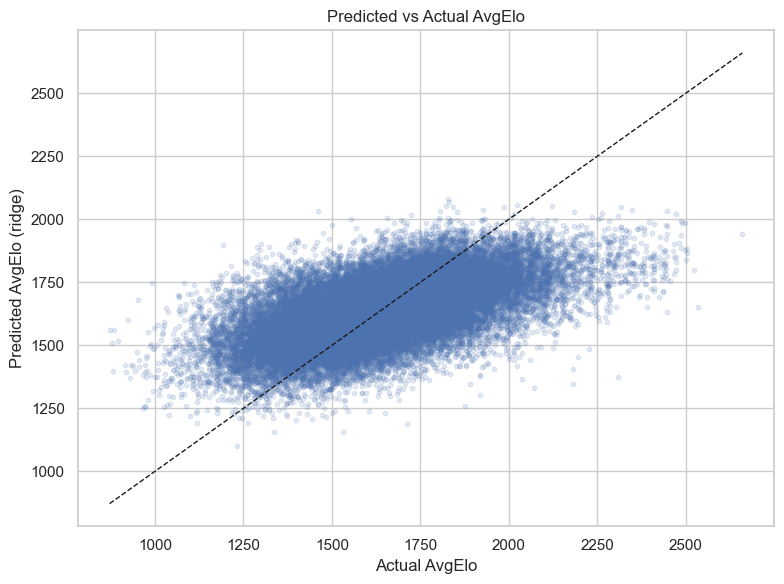

,model,split,rmse,mae,r2
0,ridge,test,183.223302,143.444642,3.356102e-01
1,hist_gradient_boosting,test,184.081194,145.046622,3.293740e-01
2,dummy_mean,test,224.869496,179.045851,-7.432148e-04
3,ridge,validation,179.697113,140.575499,3.378943e-01
4,hist_gradient_boosting,validation,180.818238,142.449133,3.296068e-01
5,dummy_mean,validation,220.839928,175.606924,-6.994281e-07


In [12]:
best_model_name = (
    metrics_df[metrics_df['split'] == 'validation']
    .sort_values('rmse')
    .iloc[0]['model']
)
best_model = models[best_model_name]

test_pred_df = pd.DataFrame({
    'GameID': df.iloc[split_2:]['GameID'].to_numpy(),
    'actual_avg_elo': y_test,
})
for name, pred in predictions.items():
    test_pred_df[f'pred_{name}'] = pred

test_pred_df.to_csv(OUTPUT_DIR / 'elo_test_predictions.csv', index=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions[best_model_name], alpha=0.15, s=10)
lims = [min(y_test.min(), predictions[best_model_name].min()), max(y_test.max(), predictions[best_model_name].max())]
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlabel('Actual AvgElo')
plt.ylabel(f'Predicted AvgElo ({best_model_name})')
plt.title('Predicted vs Actual AvgElo')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'predicted_vs_actual_avg_elo.png', dpi=200)
plt.show()

metrics_df


In [ ]:
comparison_df = metrics_df[metrics_df['split'] == 'test'].sort_values('rmse').reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='rmse', y='model', color='#2f6c8f')
plt.title('Test RMSE Comparison Across Classical ML Models')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'classical_model_test_rmse.png', dpi=200)
plt.show()

comparison_df


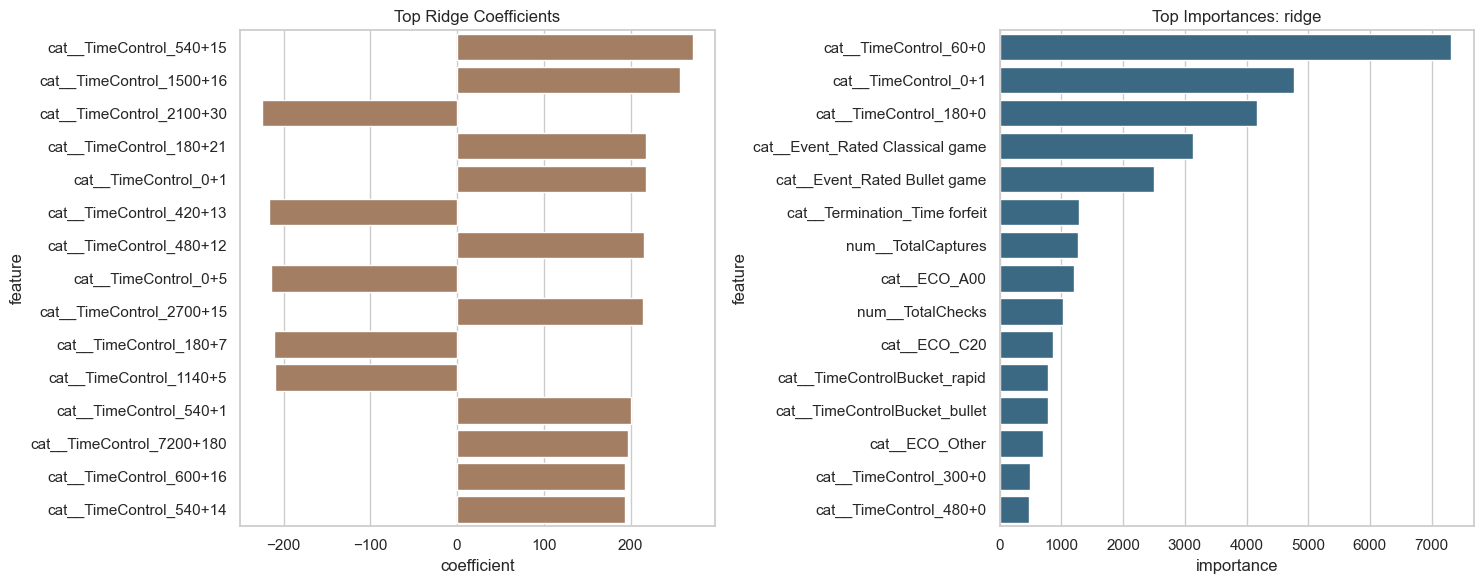

,feature,coefficient,abs_coefficient
0,cat__TimeControl_540+15,272.010083,272.010083
1,cat__TimeControl_1500+16,256.802913,256.802913
2,cat__TimeControl_2100+30,-225.033811,225.033811
3,cat__TimeControl_180+21,218.345522,218.345522
4,cat__TimeControl_0+1,217.760060,217.760060
5,cat__TimeControl_420+13,-216.763651,216.763651
6,cat__TimeControl_480+12,215.319001,215.319001
7,cat__TimeControl_0+5,-214.146590,214.146590
8,cat__TimeControl_2700+15,213.796420,213.796420
9,cat__TimeControl_180+7,-210.556560,210.556560


,feature,importance
0,cat__TimeControl_60+0,7321.866711
1,cat__TimeControl_0+1,4767.097940
2,cat__TimeControl_180+0,4170.012577
3,cat__Event_Rated Classical game,3130.062165
4,cat__Event_Rated Bullet game,2506.742802
5,cat__Termination_Time forfeit,1285.254083
6,num__TotalCaptures,1269.755802
7,cat__ECO_A00,1207.312521
8,num__TotalChecks,1020.309991
9,cat__ECO_C20,870.061988


In [13]:
ridge_model = models['ridge']
ridge_coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': ridge_model.coef_})
    .assign(abs_coefficient=lambda d: d['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
    .reset_index(drop=True)
)
ridge_coef_df.to_csv(OUTPUT_DIR / 'ridge_coefficients.csv', index=False)

perm_rows = min(len(y_val), 10000)
perm = permutation_importance(
    best_model,
    X_val_t[:perm_rows],
    y_val[:perm_rows],
    n_repeats=3,
    random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error',
)
importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': perm.importances_mean})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
importance_df.to_csv(OUTPUT_DIR / 'best_model_permutation_importance.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=ridge_coef_df.head(15), x='coefficient', y='feature', color='#ad7c59', ax=axes[0])
axes[0].set_title('Top Ridge Coefficients')

sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#2f6c8f', ax=axes[1])
axes[1].set_title(f'Top Importances: {best_model_name}')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_feature_signals.png', dpi=200)
plt.show()

display(ridge_coef_df.head(15))
display(importance_df.head(15))


## Optional PyTorch Deep Learning

This section is optional and only runs if `torch` is installed.
It uses the same preprocessed feature matrix and trains a simple multilayer perceptron for Elo regression.


In [18]:
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    TORCH_AVAILABLE = False
    print('PyTorch is not installed in this environment. Skipping deep learning section.')

TORCH_AVAILABLE


True

PyTorch device: mps


,model,split,rmse,mae,r2
0,pytorch_mlp,test,176.770893,138.308783,0.381581


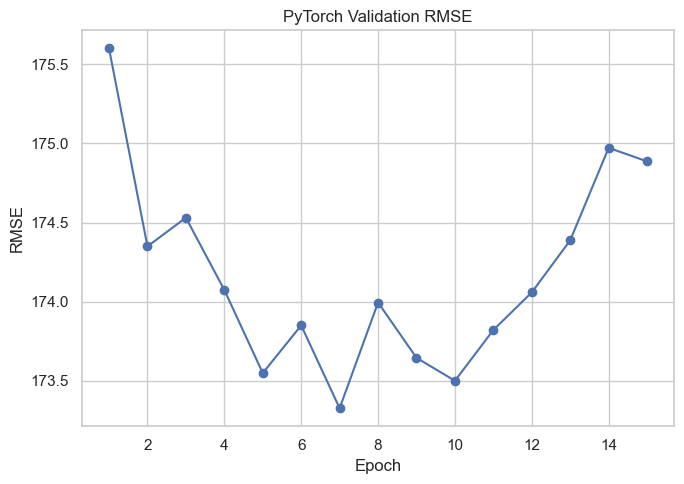

In [19]:
if TORCH_AVAILABLE:
    if torch.backends.mps.is_available():
        device = torch.device('mps')
    elif torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')

    print('PyTorch device:', device)

    target_mean = float(y_train.mean())
    target_std = float(y_train.std()) if float(y_train.std()) > 0 else 1.0
    y_train_scaled = (y_train - target_mean) / target_std
    y_val_scaled = (y_val - target_mean) / target_std
    y_test_scaled = (y_test - target_mean) / target_std

    X_train_tensor = torch.tensor(X_train_t, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_t, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_t, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_scaled.reshape(-1, 1), dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_scaled.reshape(-1, 1), dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=512, shuffle=True)

    class EloMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.Dropout(0.15),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.10),
                nn.Linear(128, 1),
            )

        def forward(self, x):
            return self.net(x)

    model = EloMLP(X_train_t.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    X_val_device = X_val_tensor.to(device)
    y_val_device = y_val_tensor.to(device)
    best_state = None
    best_val_rmse = float('inf')
    patience = 8
    patience_left = patience

    history_rows = []
    for epoch in range(1, 41):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred_scaled = model(X_val_device).cpu().numpy().ravel()
        val_pred = val_pred_scaled * target_std + target_mean
        val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
        history_rows.append({'epoch': epoch, 'val_rmse': val_rmse})

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        if patience_left == 0:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        dl_test_pred_scaled = model(X_test_tensor.to(device)).cpu().numpy().ravel()
    dl_test_pred = dl_test_pred_scaled * target_std + target_mean

    dl_metrics = pd.DataFrame([{'model': 'pytorch_mlp', 'split': 'test', **regression_metrics(y_test, dl_test_pred)}])
    display(dl_metrics)

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(OUTPUT_DIR / 'pytorch_training_history.csv', index=False)
    dl_metrics.to_csv(OUTPUT_DIR / 'pytorch_test_metrics.csv', index=False)
    dl_pred_df = pd.DataFrame({'actual_avg_elo': y_test, 'pred_pytorch_mlp': dl_test_pred})
    dl_pred_df['residual'] = dl_pred_df['pred_pytorch_mlp'] - dl_pred_df['actual_avg_elo']
    dl_pred_df.to_csv(OUTPUT_DIR / 'pytorch_test_predictions.csv', index=False)

    plt.figure(figsize=(7, 5))
    plt.plot(history_df['epoch'], history_df['val_rmse'], marker='o')
    plt.title('PyTorch Validation RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'pytorch_validation_rmse.png', dpi=200)
    plt.show()


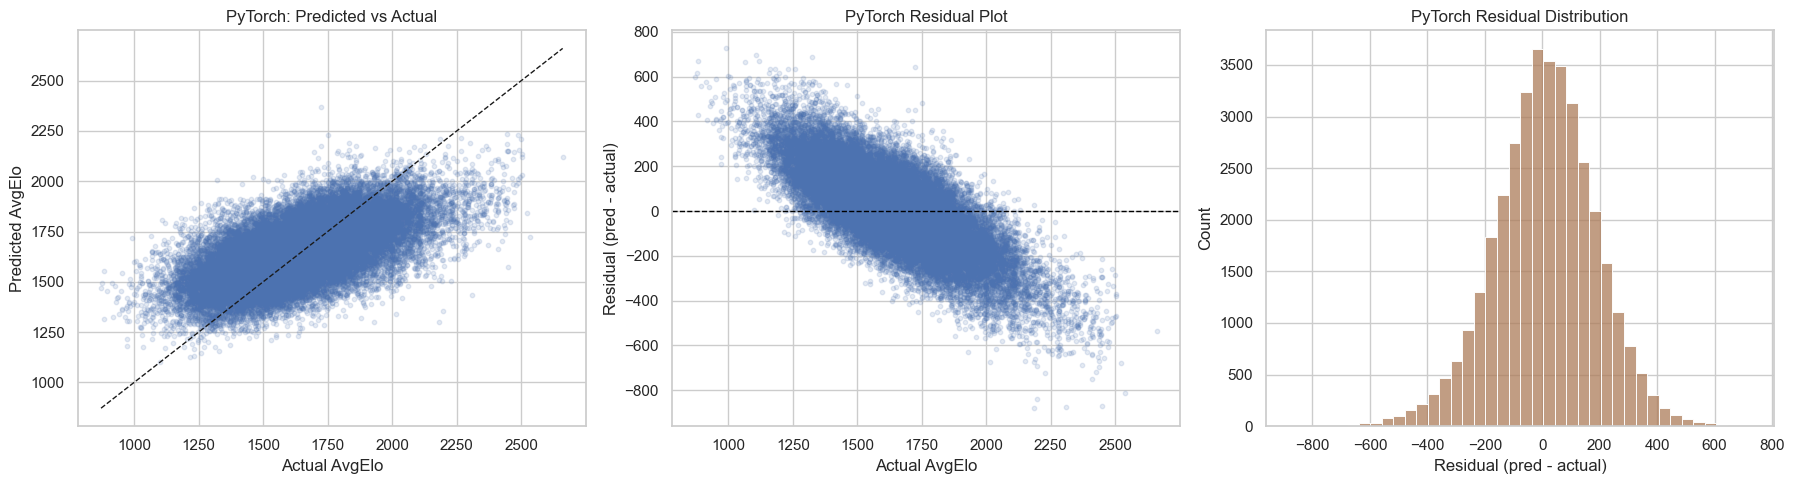

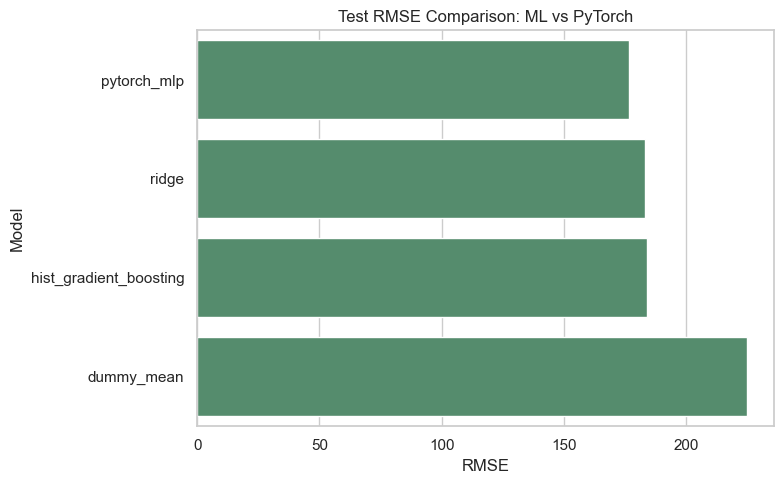

,model,rmse,mae,r2
0,pytorch_mlp,176.770893,138.308783,0.381581
1,ridge,183.223302,143.444642,0.335610
2,hist_gradient_boosting,184.081194,145.046622,0.329374
3,dummy_mean,224.869496,179.045851,-0.000743


In [20]:
if TORCH_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(dl_pred_df['actual_avg_elo'], dl_pred_df['pred_pytorch_mlp'], alpha=0.15, s=10)
    lims = [min(dl_pred_df['actual_avg_elo'].min(), dl_pred_df['pred_pytorch_mlp'].min()), max(dl_pred_df['actual_avg_elo'].max(), dl_pred_df['pred_pytorch_mlp'].max())]
    axes[0].plot(lims, lims, 'k--', linewidth=1)
    axes[0].set_title('PyTorch: Predicted vs Actual')
    axes[0].set_xlabel('Actual AvgElo')
    axes[0].set_ylabel('Predicted AvgElo')

    axes[1].scatter(dl_pred_df['actual_avg_elo'], dl_pred_df['residual'], alpha=0.15, s=10)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('PyTorch Residual Plot')
    axes[1].set_xlabel('Actual AvgElo')
    axes[1].set_ylabel('Residual (pred - actual)')

    sns.histplot(dl_pred_df['residual'], bins=40, color='#ad7c59', ax=axes[2])
    axes[2].set_title('PyTorch Residual Distribution')
    axes[2].set_xlabel('Residual (pred - actual)')
    axes[2].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'pytorch_prediction_diagnostics.png', dpi=200)
    plt.show()

    classical_test = metrics_df[metrics_df['split'] == 'test'][['model', 'rmse', 'mae', 'r2']].copy()
    combined_test = pd.concat([classical_test, dl_metrics[['model', 'rmse', 'mae', 'r2']]], axis=0).sort_values('rmse').reset_index(drop=True)
    combined_test.to_csv(OUTPUT_DIR / 'all_model_test_metrics_with_pytorch.csv', index=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=combined_test, x='rmse', y='model', color='#4c956c')
    plt.title('Test RMSE Comparison: ML vs PyTorch')
    plt.xlabel('RMSE')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'all_model_test_rmse.png', dpi=200)
    plt.show()

    display(combined_test)


## Result Insights

### Overall Performance

The deep-learning model performed best among all evaluated approaches on the test set.

| Model | RMSE | MAE | R² |
|---|---:|---:|---:|
| PyTorch MLP | 176.77 | 138.31 | 0.3816 |
| Ridge | 183.22 | 143.44 | 0.3356 |
| HistGradientBoosting | 184.08 | 145.05 | 0.3294 |
| Dummy Mean | 224.87 | 179.05 | -0.0007 |

This means the PyTorch MLP produced the lowest prediction error and the highest explained variance, outperforming both the linear baseline and the stronger tree-based baseline.

### What This Means

- The PGN-derived features contain meaningful signal for predicting player Elo.
- The deep-learning model adds value beyond simple averaging and beyond the classical baselines used here.
- The improvement over `Ridge` and `HistGradientBoosting` is meaningful, so this is a real performance gain rather than noise.
- The dummy baseline is much worse, which confirms that the model is learning actual structure rather than just regressing to the mean.

### Model Quality

The model is **good**, but not perfect.

- `RMSE = 176.77` means the model's typical Elo error is still fairly large in absolute terms.
- `R² = 0.3816` means the model explains about 38% of the variance in player strength.
- That is solid for noisy game-level chess data, but it also shows that a large share of Elo variation is still not captured by the current features.

So the correct interpretation is:

> the model is strong enough to be useful and clearly better than the tested baselines, but it is not accurate enough to treat predicted Elo as a precise replacement for the real rating.

### Training Behaviour

The validation RMSE reached its best value around epoch 7, then gradually became worse afterward. That pattern suggests mild overfitting after the best epoch, and it also shows that early stopping was helpful.

### Final Conclusion

Among the tested models, the **PyTorch MLP is the best current Elo predictor** for this project. It should be treated as the main benchmark model unless a stronger feature set or architecture is added later.
